In [9]:
print("all ok")

all ok


In [10]:
from dotenv import load_dotenv
import os
load_dotenv()


True

In [11]:
OPENAI_API_KEY=os.getenv("OPENAI_API_KEY")

In [12]:
if not OPENAI_API_KEY:
    print("OPENAI_API_KEY is missing in your .env file")
os.environ["OPENAI_API_KEY"] = OPENAI_API_KEY

In [13]:
from langchain_openai import ChatOpenAI

In [14]:

chat_llm = ChatOpenAI(model="gpt-4o-mini")

In [15]:
chat_llm.invoke("Hello, how are you?").content

"Hello! I'm just a computer program, so I don't have feelings, but I'm here and ready to help you. How can I assist you today?"

In [16]:
from typing_extensions import TypedDict,Annotated
import operator

In [17]:
from langchain_core.messages import AnyMessage, HumanMessage,AIMessage

In [18]:
class GraphState(TypedDict):
    messages: Annotated[list[AnyMessage], operator.add]

In [19]:
{
    "messages": [HumanMessage(content="Hi, this is Raja. Say hello in detail.")]
}

{'messages': [HumanMessage(content='Hi, this is Raja. Say hello in detail.', additional_kwargs={}, response_metadata={})]}

In [20]:
["hi"]

['hi']

In [21]:
["hi","how are you?"]

['hi', 'how are you?']

In [22]:
def llm_call(state: GraphState) -> dict:
    """Call the LLM using conversation messages and append AI response."""
    response = chat_llm.invoke(state["messages"])  # AIMessage
    return {
        "messages": [response]
    }

In [23]:
def token_counter(state: GraphState) -> dict:
    """Count tokens (simple word count) in the last AI message."""
    last_msg = state["messages"][-1]
    text = last_msg.content
    token_number = len(text.split())
    summary = f"Total token number in the generated answer (word count) is {token_number}"
    return {
        "messages": [AIMessage(content=summary)]
    }

In [24]:
from langgraph.graph import StateGraph

In [25]:
builder = StateGraph(GraphState)

In [26]:
builder.add_node("llm_call", llm_call)
builder.add_node("token_counter", token_counter)

In [27]:
builder.set_entry_point("llm_call")
builder.add_edge("llm_call", "token_counter")
builder.set_finish_point("token_counter")

In [28]:
app = builder.compile()

In [29]:
app.get_graph()

Graph(nodes={'__start__': Node(id='__start__', name='__start__', data=RunnableCallable(tags=None, recurse=True, explode_args=False, func_accepts={}), metadata=None), 'llm_call': Node(id='llm_call', name='llm_call', data=llm_call(tags=None, recurse=True, explode_args=False, func_accepts={}), metadata=None), 'token_counter': Node(id='token_counter', name='token_counter', data=token_counter(tags=None, recurse=True, explode_args=False, func_accepts={}), metadata=None), '__end__': Node(id='__end__', name='__end__', data=None, metadata=None)}, edges=[Edge(source='__start__', target='llm_call', data=None, conditional=False), Edge(source='llm_call', target='token_counter', data=None, conditional=False), Edge(source='token_counter', target='__end__', data=None, conditional=False)])

In [30]:
from IPython.display import Image, display

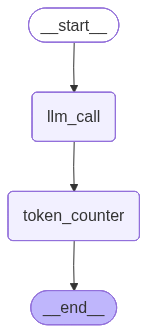

In [31]:
display(Image(app.get_graph().draw_mermaid_png()))

In [32]:
result = app.invoke({
    "messages": [HumanMessage(content="Hi, this is Raja. Say hello in detail.")]
})

In [33]:
result

{'messages': [HumanMessage(content='Hi, this is Raja. Say hello in detail.', additional_kwargs={}, response_metadata={}),
  AIMessage(content="Hello, Raja! It's a pleasure to connect with you. I hope you're having a wonderful day. Whether you're here to ask questions, seek information, or just chat, I'm here to assist you. Is there something specific you'd like to know about, or perhaps a particular topic you're interested in discussing? Feel free to share!", additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 65, 'prompt_tokens': 18, 'total_tokens': 83, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_e155db4643', 'id': 'chatcmpl-DQRQmd7TUskdcX2u4k9NeC1VZGZTS', 'service_tier': 'default', 'finish_re

In [34]:
for m in result["messages"]:
    print(type(m).__name__, ":", m.content)

HumanMessage : Hi, this is Raja. Say hello in detail.
AIMessage : Hello, Raja! It's a pleasure to connect with you. I hope you're having a wonderful day. Whether you're here to ask questions, seek information, or just chat, I'm here to assist you. Is there something specific you'd like to know about, or perhaps a particular topic you're interested in discussing? Feel free to share!
AIMessage : Total token number in the generated answer (word count) is 54


In [35]:
chat_llm

ChatOpenAI(profile={'name': 'GPT-4o mini', 'release_date': '2024-07-18', 'last_updated': '2024-07-18', 'open_weights': False, 'max_input_tokens': 128000, 'max_output_tokens': 16384, 'text_inputs': True, 'image_inputs': True, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True, 'structured_output': True, 'attachment': True, 'temperature': True, 'image_url_inputs': True, 'pdf_inputs': True, 'pdf_tool_message': True, 'image_tool_message': True, 'tool_choice': True}, client=<openai.resources.chat.completions.completions.Completions object at 0x0000016BDEA2E930>, async_client=<openai.resources.chat.completions.completions.AsyncCompletions object at 0x0000016BE002AA20>, root_client=<openai.OpenAI object at 0x0000016BDFA6A390>, root_async_client=<openai.AsyncOpenAI object at 0x0000016BDFA6A810>, model_name='gpt-4o-mini', model_kwargs={}, openai_api_key=Secret

In [36]:
from langchain_community.tools import WikipediaQueryRun
from langchain_community.utilities import WikipediaAPIWrapper

In [37]:
api_wrapper=WikipediaAPIWrapper(top_k_results=5,doc_content_chars_max= 500)

In [38]:
wiki_tool=WikipediaQueryRun(api_wrapper=api_wrapper)

In [39]:
wiki_tool.run({"query":"Generative AI"})

'Page: Generative AI\nSummary: Generative artificial intelligence, also known as generative AI or GenAI, is a subfield of artificial intelligence that uses generative models to generate text, images, videos, audio, software code or other forms of data. These models learn the underlying patterns and structures of their training data, and use them to generate new data in response to input, which often takes the form of natural language prompts.\nThe prevalence of generative AI tools has increased sig'

In [40]:
import os
from langchain_community.tools.tavily_search import TavilySearchResults
TAVILY_API_KEY=os.getenv("TAVILY_API_KEY")

In [42]:
tool=TavilySearchResults(tavily_api_key=TAVILY_API_KEY)

In [43]:
tool.invoke({"query":"how is the job market for fresh graduates in 2026?"})

[{'title': 'From Graduation to Career: Job Market Trends for 2026',
  'url': 'https://www.diplomaframe.com/chc-blog/from-graduation-to-career-job-market-trends-for-2025/?srsltid=AfmBOopC6r214kDMY4YoOHgk0x40zoNj8gVUoqeXXsFOiOQjMmbDsFkc',
  'content': '## Church Hill Classics Blog\n\nDo not edit this section.\n\nTo change the post title text, click the settings gear icon in the lower left of your screen while editing the post in elementor.\n\nIf you are seeing this message, please navigate back to the previous page to the edit post area.\n\n Updated on\n By Emma Becker\n In Business Tips, College, Job Search & Business Tips\n\nNothing is more exciting and rewarding than graduating from college. However, are you ready for graduation this year? More importantly, are you prepared to enter the realm of employment and establish your career?\n\nFret not, as this page shares with you the job market trends to explore in 2026. As a fresh graduate, learn how to prepare yourself for the world of em

In [44]:
from langchain_community.tools import DuckDuckGoSearchRun
search=DuckDuckGoSearchRun()

In [45]:
search.invoke("what is the latest update on iphone17 release?")

'ThelatestiPhoneupdateishere and brings major new features as well as bug fixes. Apple has unveiled four new iPhones: theiPhone17,iPhone Air,iPhone17Pro andiPhone17Pro Max. Here\'s the lowdown on the specs, price, new features, design, dimensions and more. Apple has unveiled theiPhone17during its "Awe Dropping" event, showcasing all the improvements, colors and more. Apple launched its newiPhone17lineup and ultra-thin iPhone Air in September 2025. TheiPhone17isApple\'s most affordable flagship iPhone, sold alongside the higher-end iPhone Air,iPhone17... TheiPhone17rolls out with some designupdates, pretty slim bezels, a bright and bigger display with a 120Hz refresh rate. Apart from that, its design remains pretty much familiar to iPhone fans, unlike the Pro models and the new Air model.'

In [ ]:
## bingsearch, googleserperapi

In [46]:
from langchain_community.tools import YouTubeSearchTool

In [47]:
tool=YouTubeSearchTool()

In [48]:
tool.name

'youtube_search'

In [49]:
tool.description

'search for youtube videos associated with a person. the input to this tool should be a comma separated list, the first part contains a person name and the second a number that is the maximum number of video results to return aka num_results. the second part is optional'

In [50]:
tool.run("krish naik")

"['https://www.youtube.com/watch?v=JxgmHe2NyeY&pp=ygUKa3Jpc2ggbmFpaw%3D%3D', 'https://www.youtube.com/watch?v=LZzq1zSL1bs&pp=ygUKa3Jpc2ggbmFpaw%3D%3D']"

In [51]:
tool.run("sunny savita")

"['https://www.youtube.com/watch?v=ImbmSEPo7qI&pp=ygUMc3Vubnkgc2F2aXRh', 'https://www.youtube.com/watch?v=ENzZuvahKwc&pp=ygUMc3Vubnkgc2F2aXRh']"

In [52]:
def multiply(a:int,b:int) -> int:
    return a*b

In [53]:
multiply(10,20)

200

In [54]:
multiply.invoke(10,20)

AttributeError: 'function' object has no attribute 'invoke'

In [55]:
multiply.invoke({"a":10,"b":20})

AttributeError: 'function' object has no attribute 'invoke'

In [56]:
from langchain.tools import tool

In [57]:
@tool
def multiply(a:int,b:int) -> int:
    '''this tool is for the multiplication'''
    return a*b

In [58]:
multiply.invoke({"a":10,"b":20})

200

In [59]:
multiply.name

'multiply'

In [60]:
multiply.description

'this tool is for the multiplication'

In [61]:
multiply.args

{'a': {'title': 'A', 'type': 'integer'},
 'b': {'title': 'B', 'type': 'integer'}}

In [62]:
@tool
def get_word_length(word:str) -> int:
    """it is a tool to count the length of the word"""
    return len(word)

In [63]:
get_word_length.invoke("hello world")

11

In [64]:
get_word_length.invoke({"word": "hello world"})

11

In [65]:
@tool
def call_gmail_api(args):
    """this is a tool to call gmail api""" 
    pass

In [66]:
@tool
def call_sqllite_db(args):
    """this is a tool to call sqllite db""" 
    pass

In [67]:
import yfinance as yf

In [68]:
@tool
def get_stock_price(ticker:str) -> str: 
    """this is a tool to get stock price using yfinance"""
    try:
        stock = yf.Ticker(ticker)

        # Get last 1 day historical data
        data = stock.history(period="1d")

        if data.empty:
            return f"No data found for ticker '{ticker}'. Please check the symbol."

        latest_close = data["Close"].iloc[-1]

        # Detect currency
        currency = stock.info.get("currency", "")
        symbol_map = {
            "INR": "₹",
            "USD": "$",
            "EUR": "€",
            "GBP": "£"
        }

        symbol = symbol_map.get(currency, "")
        currency_text = currency if currency else ""

        if symbol:
            return f"The last closing price of {ticker.upper()} was {symbol}{latest_close:.2f}."
        else:
            return f"The last closing price of {ticker.upper()} was {latest_close:.2f} {currency_text}."

    except Exception as e:
        return f"An error occurred while fetching stock data: {str(e)}"

In [69]:
get_stock_price.invoke("TCS.NS")

'The last closing price of TCS.NS was ₹2450.70.'

In [70]:
get_stock_price.invoke("AAPL")

'The last closing price of AAPL was $255.92.'

In [71]:
get_stock_price.invoke("TSLA")

'The last closing price of TSLA was $360.59.'

In [72]:
get_stock_price.invoke("HDFCBANK.NS")

'The last closing price of HDFCBANK.NS was ₹750.90.'

In [73]:
[get_stock_price,get_word_length,multiply]

[StructuredTool(name='get_stock_price', description='this is a tool to get stock price using yfinance', args_schema=<class 'langchain_core.utils.pydantic.get_stock_price'>, func=<function get_stock_price at 0x0000016BF18EA480>),
 StructuredTool(name='get_word_length', description='it is a tool to count the length of the word', args_schema=<class 'langchain_core.utils.pydantic.get_word_length'>, func=<function get_word_length at 0x0000016BE15EE8E0>),
 StructuredTool(name='multiply', description='this tool is for the multiplication', args_schema=<class 'langchain_core.utils.pydantic.multiply'>, func=<function multiply at 0x0000016BE15B6200>)]

In [74]:
tools = [get_stock_price,get_word_length,multiply,wiki_tool]

In [75]:
chat_llm

ChatOpenAI(profile={'name': 'GPT-4o mini', 'release_date': '2024-07-18', 'last_updated': '2024-07-18', 'open_weights': False, 'max_input_tokens': 128000, 'max_output_tokens': 16384, 'text_inputs': True, 'image_inputs': True, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True, 'structured_output': True, 'attachment': True, 'temperature': True, 'image_url_inputs': True, 'pdf_inputs': True, 'pdf_tool_message': True, 'image_tool_message': True, 'tool_choice': True}, client=<openai.resources.chat.completions.completions.Completions object at 0x0000016BDEA2E930>, async_client=<openai.resources.chat.completions.completions.AsyncCompletions object at 0x0000016BE002AA20>, root_client=<openai.OpenAI object at 0x0000016BDFA6A390>, root_async_client=<openai.AsyncOpenAI object at 0x0000016BDFA6A810>, model_name='gpt-4o-mini', model_kwargs={}, openai_api_key=Secret

In [76]:
llm_with_tools=chat_llm.bind_tools(tools)

In [77]:
chat_llm

ChatOpenAI(profile={'name': 'GPT-4o mini', 'release_date': '2024-07-18', 'last_updated': '2024-07-18', 'open_weights': False, 'max_input_tokens': 128000, 'max_output_tokens': 16384, 'text_inputs': True, 'image_inputs': True, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True, 'structured_output': True, 'attachment': True, 'temperature': True, 'image_url_inputs': True, 'pdf_inputs': True, 'pdf_tool_message': True, 'image_tool_message': True, 'tool_choice': True}, client=<openai.resources.chat.completions.completions.Completions object at 0x0000016BDEA2E930>, async_client=<openai.resources.chat.completions.completions.AsyncCompletions object at 0x0000016BE002AA20>, root_client=<openai.OpenAI object at 0x0000016BDFA6A390>, root_async_client=<openai.AsyncOpenAI object at 0x0000016BDFA6A810>, model_name='gpt-4o-mini', model_kwargs={}, openai_api_key=Secret

In [78]:
result = llm_with_tools.invoke("what is the stock price of TCS.NS?")

In [79]:
result

AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 18, 'prompt_tokens': 170, 'total_tokens': 188, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_2e9401d89c', 'id': 'chatcmpl-DQRqX1SlreVHkp0P7iwJrki7QAnKB', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019d51ec-62ba-78b0-91a4-01c46924ceaf-0', tool_calls=[{'name': 'get_stock_price', 'args': {'ticker': 'TCS.NS'}, 'id': 'call_0TAdtBKkghVwTUWMQcsnx2Vm', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 170, 'output_tokens': 18, 'total_tokens': 188, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}})

In [80]:
result.content

''

In [81]:
result.tool_calls

[{'name': 'get_stock_price',
  'args': {'ticker': 'TCS.NS'},
  'id': 'call_0TAdtBKkghVwTUWMQcsnx2Vm',
  'type': 'tool_call'}]

In [82]:
result = llm_with_tools.invoke("how many words are there in the sentence 'hello world, this is a test sentence?'")

In [83]:
result.content

''

In [84]:
result.tool_calls

[{'name': 'get_word_length',
  'args': {'word': 'hello world, this is a test sentence'},
  'id': 'call_YIxWqr4vYszu0WbJNzA2bm7h',
  'type': 'tool_call'}]

In [85]:
result = llm_with_tools.invoke("can you multiply 10 and 20?")

In [86]:
result.content

''

In [87]:
result.tool_calls

[{'name': 'multiply',
  'args': {'a': 10, 'b': 20},
  'id': 'call_hyTJJYW9E4BBcLSKIMzgl45G',
  'type': 'tool_call'}]

In [88]:
result = llm_with_tools.invoke("hi how are you?")

In [89]:
result.content

"I'm just a program, so I don't have feelings, but I'm here and ready to help you! How can I assist you today?"

In [90]:
result.tool_calls

[]

In [91]:
result = llm_with_tools.invoke("what was in the latest indian union budget report of 2026?")

In [92]:
result.content

''

In [93]:
result.tool_calls

[{'name': 'wikipedia',
  'args': {'query': 'India Union Budget 2026'},
  'id': 'call_pzfHK7e3nLmsORAjucyGjEwR',
  'type': 'tool_call'}]

In [94]:
result = llm_with_tools.invoke("what was in the latest indian union budget report of 2026?")

In [95]:
result.content

''

In [96]:
result.tool_calls

[{'name': 'wikipedia',
  'args': {'query': 'Indian Union Budget 2026'},
  'id': 'call_adfh3R7QGdV45IN3ofqJaXap',
  'type': 'tool_call'}]

In [97]:
from langchain_core.messages import HumanMessage, SystemMessage
from langgraph.graph import MessagesState,StateGraph, END, START
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

In [98]:
SYSTEM_PROMPT = SystemMessage(content="You are a helpful assistant that can use tools to answer questions.")

In [99]:
def function_1(state:MessagesState):
    user_question=state["messages"]
    input_question =[SYSTEM_PROMPT] + user_question
    response = llm_with_tools.invoke(input_question)
    return{
        "messages":[response]
    }

In [100]:
tools

[StructuredTool(name='get_stock_price', description='this is a tool to get stock price using yfinance', args_schema=<class 'langchain_core.utils.pydantic.get_stock_price'>, func=<function get_stock_price at 0x0000016BF18EA480>),
 StructuredTool(name='get_word_length', description='it is a tool to count the length of the word', args_schema=<class 'langchain_core.utils.pydantic.get_word_length'>, func=<function get_word_length at 0x0000016BE15EE8E0>),
 StructuredTool(name='multiply', description='this tool is for the multiplication', args_schema=<class 'langchain_core.utils.pydantic.multiply'>, func=<function multiply at 0x0000016BE15B6200>),
 WikipediaQueryRun(api_wrapper=WikipediaAPIWrapper(wiki_client=<module 'wikipedia' from 'd:\\AIML\\Build AI Agents\\yt-live-crash-course\\env\\Lib\\site-packages\\wikipedia\\__init__.py'>, top_k_results=5, lang='en', load_all_available_meta=False, doc_content_chars_max=500))]

In [101]:
function_2 = ToolNode(tools)

In [102]:
workflow = StateGraph(MessagesState)

In [103]:
workflow.add_node("llm", function_1)

In [104]:
workflow.add_node("tools", function_2)

In [105]:
workflow.add_edge(START, "llm")

In [106]:
workflow.add_conditional_edges(
    "llm",
    tools_condition,
)

In [107]:
workflow.add_edge("tools", "llm")

In [108]:
app = workflow.compile()

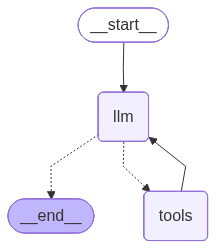

In [109]:
from IPython.display import Image, display
display(Image(app.get_graph(xray=True).draw_mermaid_png()))

In [110]:
result = app.invoke({
    "messages": [HumanMessage(content="what is the stock price of TCS.NS?")]
})

In [111]:
for m in result['messages']:
    m.pretty_print()

================================ Human Message =================================

what is the stock price of TCS.NS?
================================== Ai Message ==================================
Tool Calls:
  get_stock_price (call_ccy6skcPHQXfxth4B5USISjJ)
 Call ID: call_ccy6skcPHQXfxth4B5USISjJ
  Args:
    ticker: TCS.NS
================================= Tool Message =================================
Name: get_stock_price

The last closing price of TCS.NS was ₹2450.70.
================================== Ai Message ==================================

The last closing price of TCS.NS was ₹2450.70.


In [112]:
result = app.invoke({
    "messages": [HumanMessage(content="what was in the latest indian union budget report of 2026?")]
})

In [113]:
for m in result['messages']:
    m.pretty_print()

================================ Human Message =================================

what was in the latest indian union budget report of 2026?
================================== Ai Message ==================================
Tool Calls:
  wikipedia (call_Hi7JpaWMTJtxwQ1GAH8aeu19)
 Call ID: call_Hi7JpaWMTJtxwQ1GAH8aeu19
  Args:
    query: Indian Union Budget 2026
================================= Tool Message =================================
Name: wikipedia

Page: 2026 Union budget of India
Summary: The Union Budget of India for 2026–27 was presented on 1 February 2026 in the Lok Sabha by Finance Minister Nirmala Sitharaman on behalf of the Third Modi ministry. The budget outlined the Government of India's fiscal policy, taxation proposals, and expenditure priorities for the financial year 2026–27.
According to the Press Information Bureau (PIB), India's real GDP growth for 2025–26 was estimated at 7.4%, with nominal growth projected at 10% for 2026
================================== Ai M

In [114]:
result = app.invoke({
    "messages": [HumanMessage(content="give me the latest AI news count the length of response and multiply that response with the 10.")]
})

In [115]:
for m in result['messages']:
    m.pretty_print()

================================ Human Message =================================

give me the latest AI news count the length of response and multiply that response with the 10.
================================== Ai Message ==================================
Tool Calls:
  wikipedia (call_5w3WSjPesK5KBEQSkfLongww)
 Call ID: call_5w3WSjPesK5KBEQSkfLongww
  Args:
    query: latest news on artificial intelligence
================================= Tool Message =================================
Name: wikipedia

Page: Artificial Intelligence Act
Summary: The Artificial Intelligence Act (AI Act) is a European Union regulation concerning artificial intelligence (AI). It establishes a common regulatory and legal framework for AI within the European Union (EU). The regulation entered into force on 1 August 2024, with provisions that shall come into operation gradually over the following 6 to 36 months.
It covers most AI systems across a wide range of sectors, with exemptions for AI used only for 

In [116]:
result = app.invoke({
    "messages": [HumanMessage(content="how did trump's tariff policy impact the TCS.NS?")]
})

In [117]:
for m in result['messages']:
    m.pretty_print()

================================ Human Message =================================

how did trump's tariff policy impact the TCS.NS?
================================== Ai Message ==================================
Tool Calls:
  wikipedia (call_QbqxClvdVp1zW3tJJ0PqZzj0)
 Call ID: call_QbqxClvdVp1zW3tJJ0PqZzj0
  Args:
    query: Trump tariff policy
================================= Tool Message =================================
Name: wikipedia

Page: Tariffs in the second Trump administration
Summary: During his second term as President of the United States, Donald Trump enacted a series of steep tariffs affecting nearly all goods imported into the country. From January to April 2025, the overall average effective US tariff rate rose from 2.5% to an estimated 27%—the highest level in over a century. After changes, negotiations, and the invalidation of certain tariffs by the Supreme Court of the United States, the overall average effect
================================== Ai Message ========